In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import xgboost as xgb

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("数据集样本数：", df.shape[0])
print("特征数量：", df.shape[1]-1)
print("目标变量分布：\n", df['target'].value_counts())

数据集样本数： 569
特征数量： 30
目标变量分布：
 target
1    357
0    212
Name: count, dtype: int64


In [3]:
df.isnull()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
565,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
566,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
567,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull().sum(axis=0).sum()

np.int64(0)

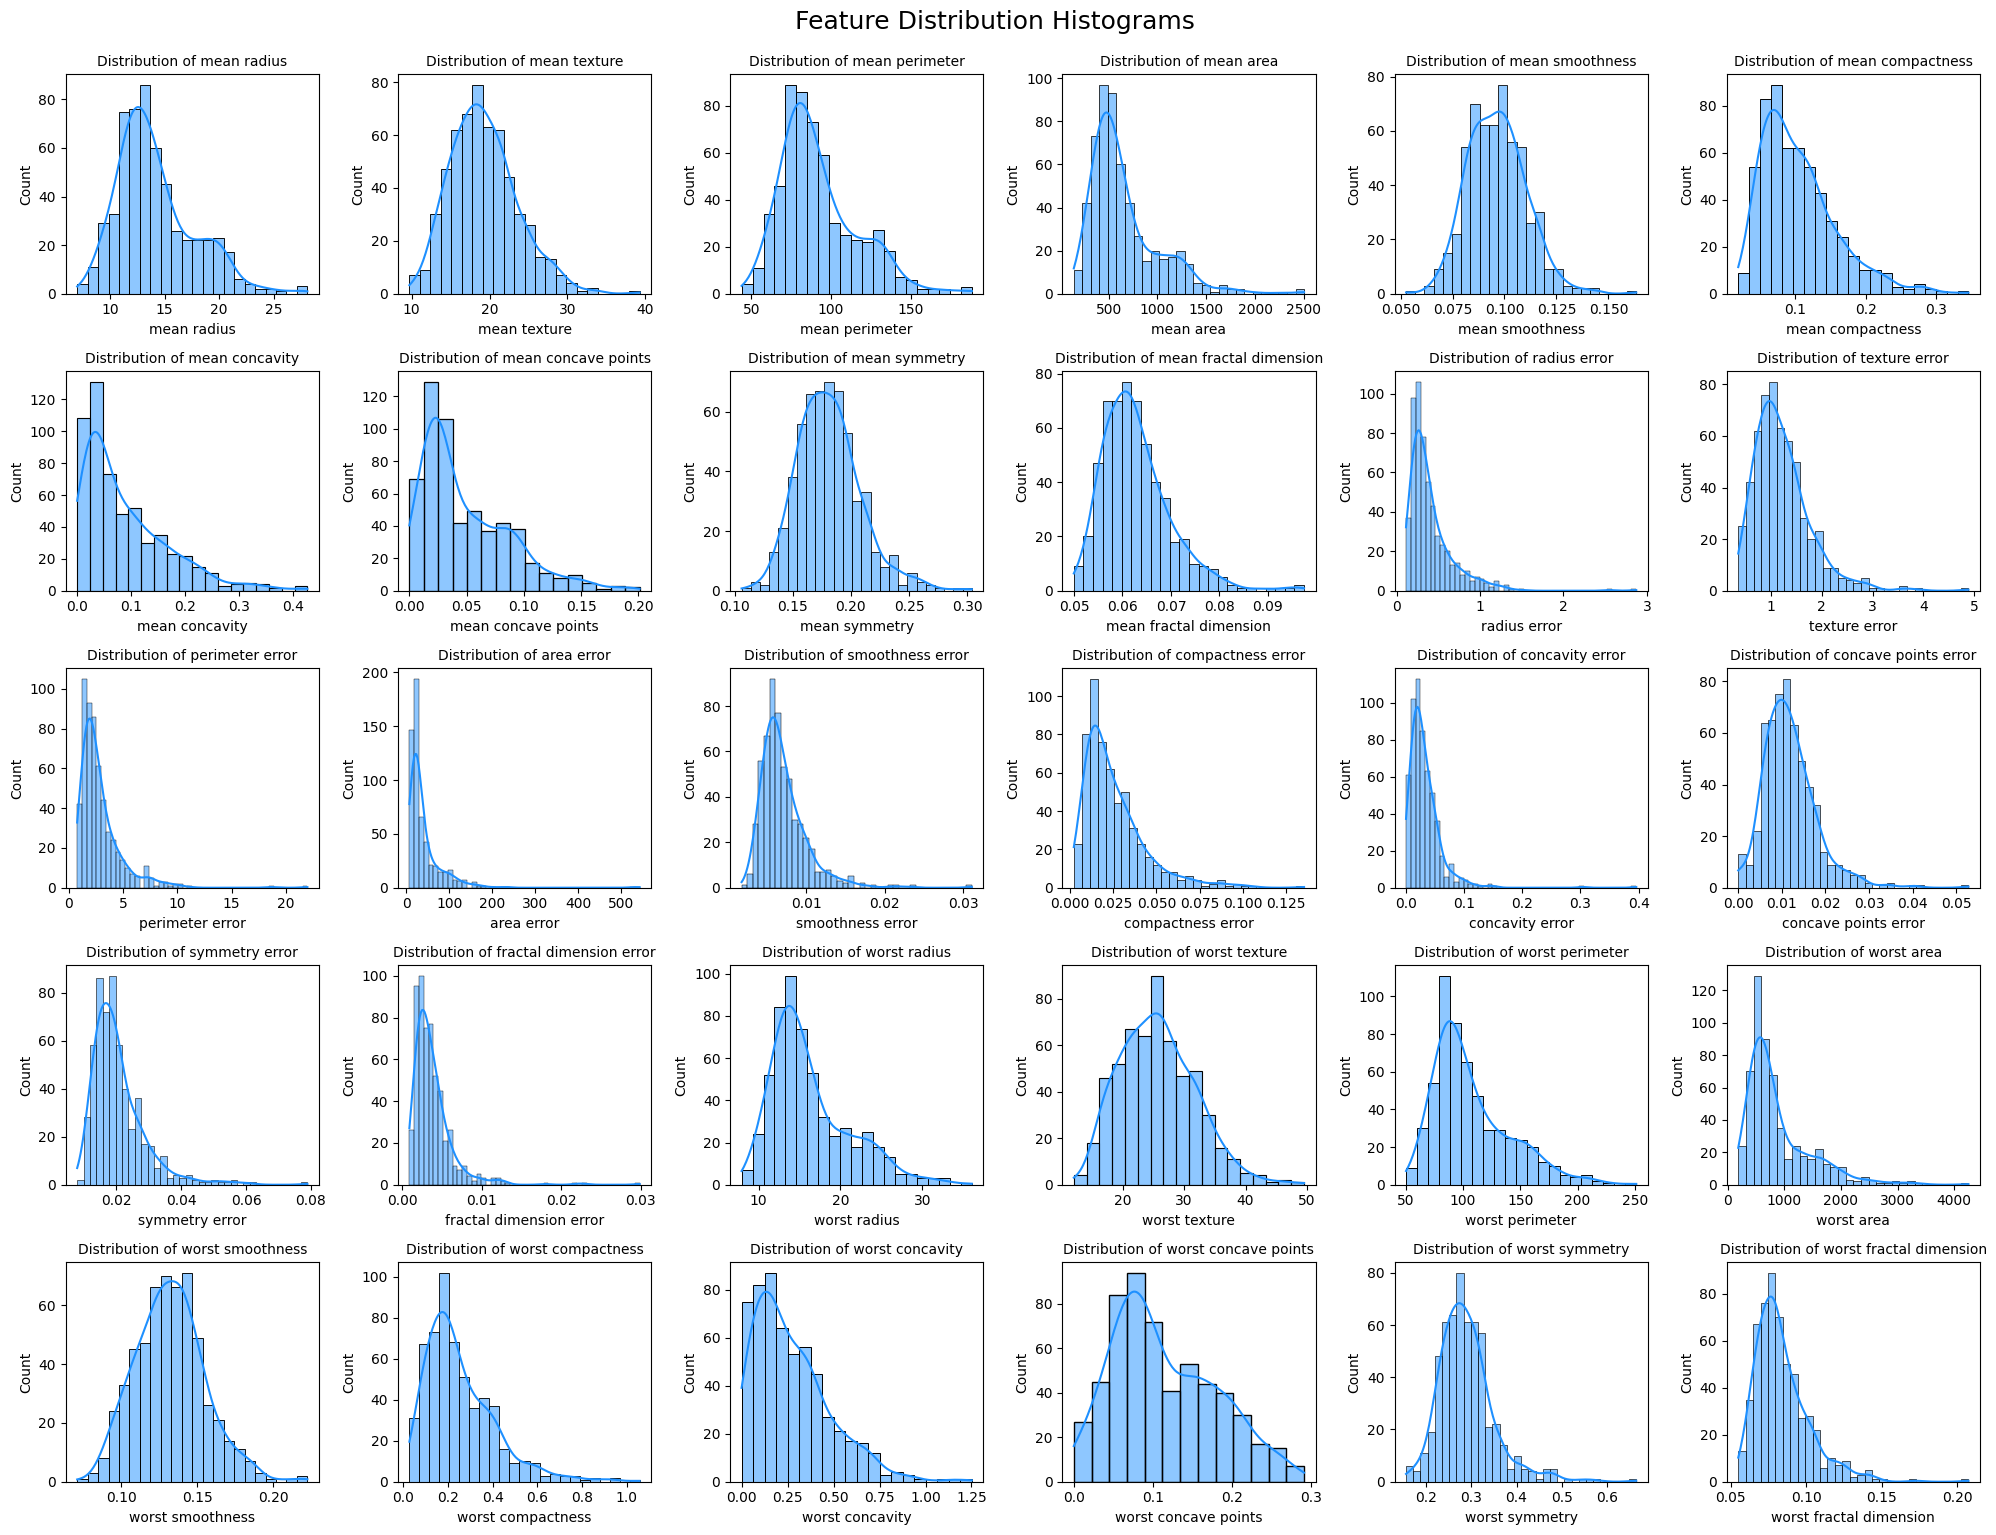

In [10]:
df_features = df.drop('target', axis=1)
fig, axes = plt.subplots(5, 6, figsize=(20, 15))
axes = axes.flatten()
for i, col in enumerate(df_features.columns):
    sns.histplot(df_features[col], ax=axes[i], kde=True, color='dodgerblue')
    axes[i].set_title(f"Distribution of {col}", fontsize=10)
plt.tight_layout()
plt.suptitle("Feature Distribution Histograms", fontsize=18, y=1.02)
plt.show()

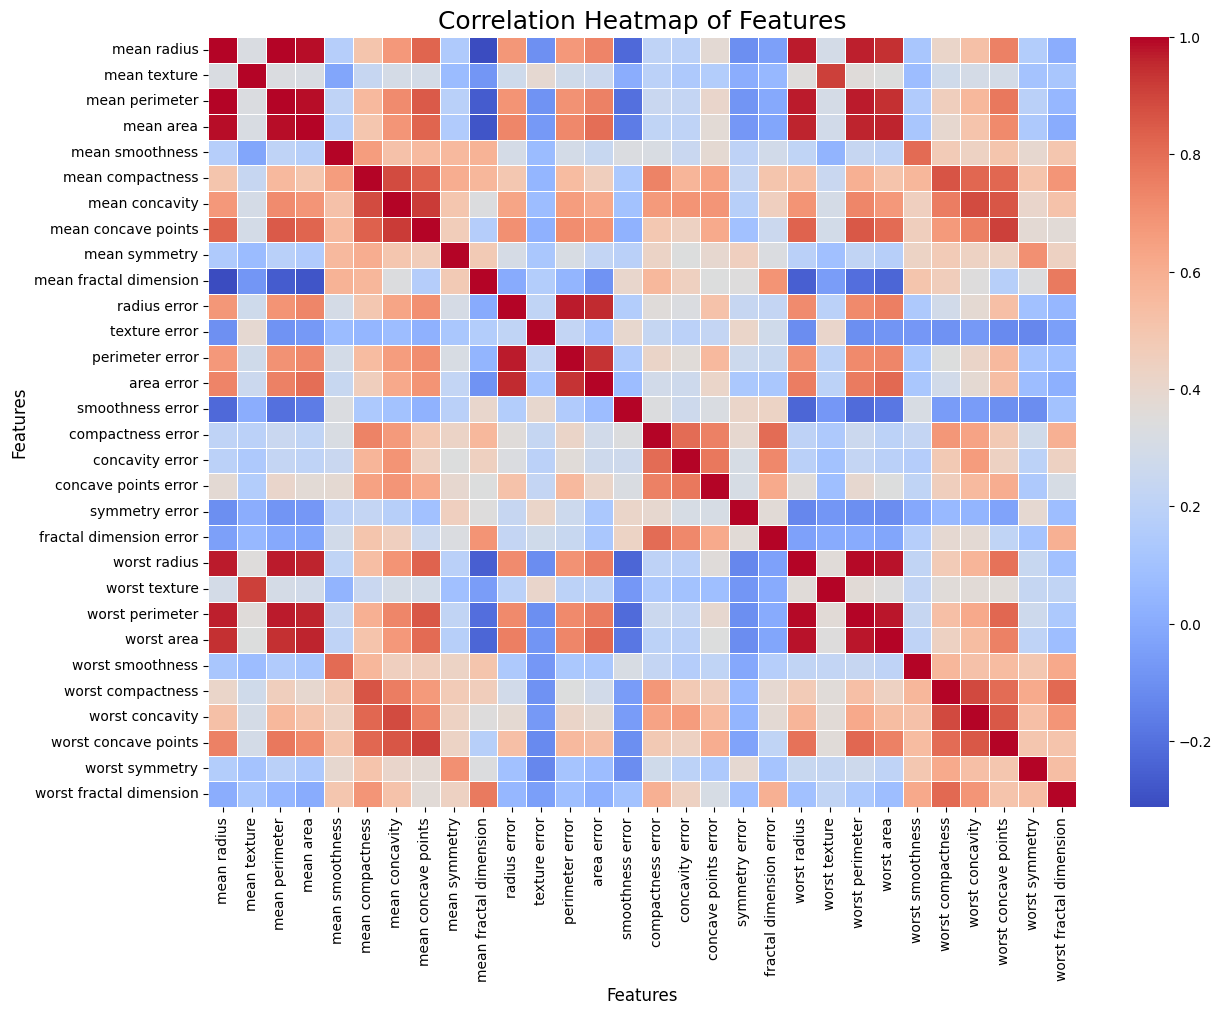

In [11]:
corr_matrix = df_features.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Features", fontsize=18)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.show()

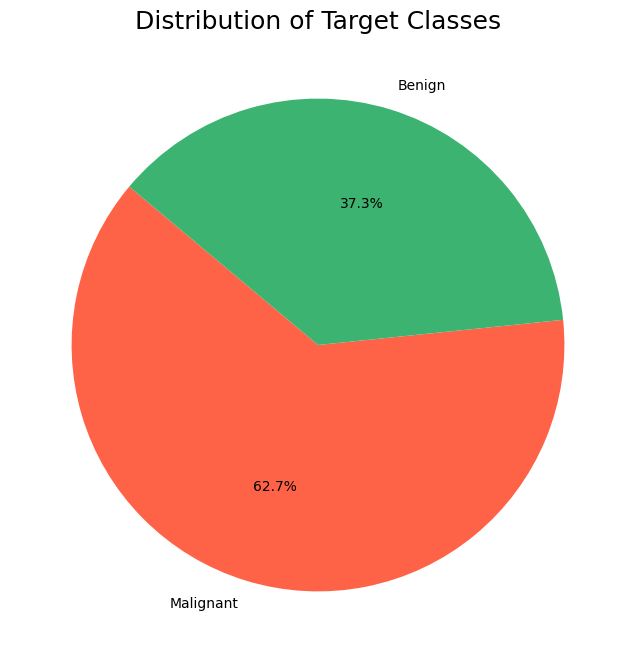

In [13]:
plt.figure(figsize=(8, 8))
target_counts = df['target'].value_counts()
plt.pie(target_counts, labels=["Malignant", "Benign"], autopct='%1.1f%%', colors=["tomato", "mediumseagreen"], startangle=140)
plt.title("Distribution of Target Classes", fontsize=18)
plt.show()

In [14]:
X = df_features
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
xgb_clf = xgb.XGBClassifier(eval_metric='logloss', random_state=42)  # 前者是默认的
xgb_clf.fit(X_train, y_train)
y_pred = xgb_clf.predict(X_test)

              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



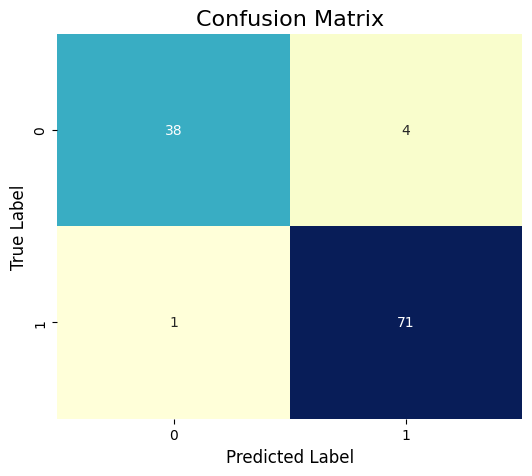

In [16]:
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", cbar=False)
plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()

In [18]:
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 150],
    'subsample': [0.8, 0.9, 1.0],  # 每棵树使用的样本比例（行采样）
    'colsample_bytree': [0.6, 0.8, 1.0],  # 每棵树使用的特征比例（列采样）
    'gamma': [0, 0.1, 0.2]  # 分裂节点所需的最小损失减少量
}

grid_search = GridSearchCV(estimator=xgb.XGBClassifier(eval_metric='logloss', random_state=42),
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=5,
                           verbose=1
                           )

grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy found: ", grid_search.best_score_)

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Best parameters found:  {'colsample_bytree': 0.6, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.9}
Best accuracy found:  0.9802197802197803


In [20]:
best_params = grid_search.best_params_
xgb_clf_best = xgb.XGBClassifier(**best_params, eval_metric='logloss', random_state=42, early_stopping_rounds=20)
xgb_clf_best.fit(X_train, y_train,
                 eval_set=[(X_test, y_test)],
                 verbose=False)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.6
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method="

              precision    recall  f1-score   support

           0       0.93      0.90      0.92        42
           1       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



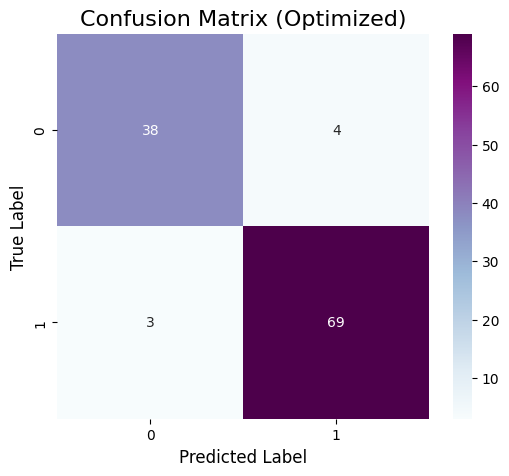

In [22]:
y_pred_best = xgb_clf_best.predict(X_test)
print(classification_report(y_test, y_pred_best))
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap="BuPu", cbar=True)
plt.title("Confusion Matrix (Optimized)", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()

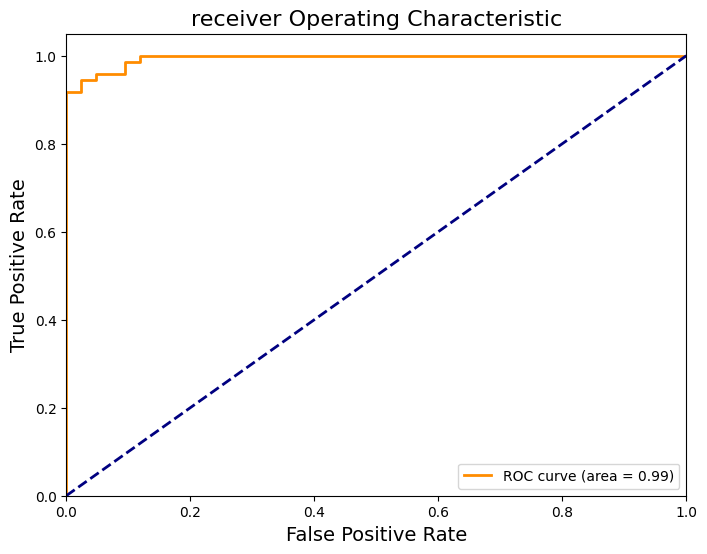

In [27]:
y_pred_proba = xgb_clf_best.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('receiver Operating Characteristic', fontsize=16)
plt.legend(loc="best")
plt.show()

<Figure size 1200x800 with 0 Axes>

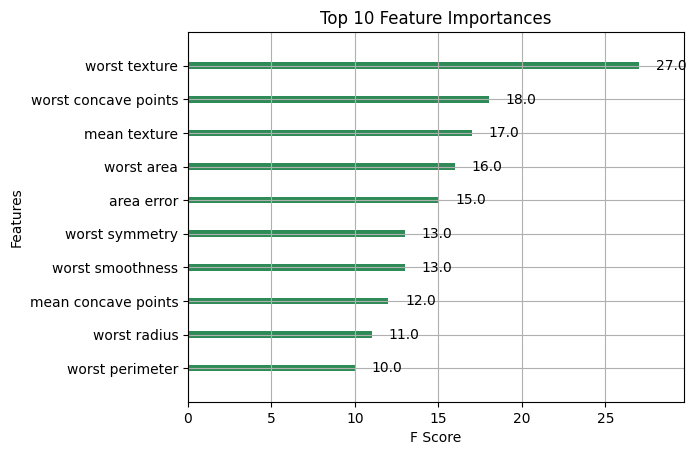

In [28]:
plt.figure(figsize=(12, 8))
xgb.plot_importance(xgb_clf_best, max_num_features=10, color='seagreen', title="Top 10 Feature Importances", xlabel="F Score", ylabel="Features")
plt.show()

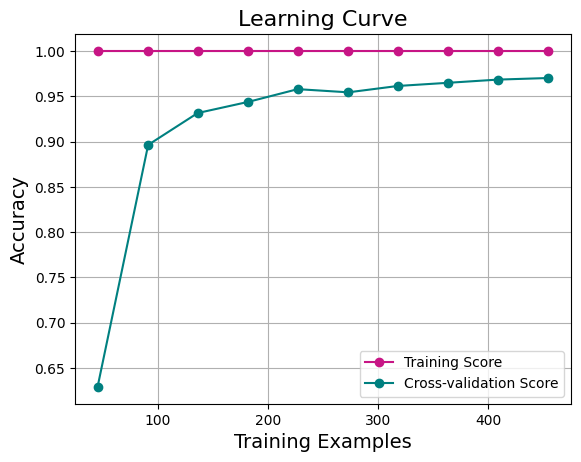

In [30]:
from sklearn.model_selection import learning_curve

xgb_clf_best_for_lc = xgb_clf_best
xgb_clf_best_for_lc.early_stopping_rounds = None  # Disable early stopping for learning curve

train_sizes, train_scores, test_scores = learning_curve(xgb_clf_best_for_lc, X, y, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10))

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_scores_mean, 'o-', color='mediumvioletred', label='Training Score')
plt.plot(train_sizes, test_scores_mean, 'o-', color='teal', label='Cross-validation Score')
plt.xlabel('Training Examples', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Learning Curve', fontsize=16)
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [31]:
train_scores

array([[1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.]])

In [32]:
test_scores

array([[0.61403509, 0.69298246, 0.71052632, 0.55263158, 0.57522124],
       [0.8245614 , 0.94736842, 0.92982456, 0.90350877, 0.87610619],
       [0.90350877, 0.94736842, 0.97368421, 0.92105263, 0.91150442],
       [0.92105263, 0.93859649, 0.98245614, 0.93859649, 0.9380531 ],
       [0.92105263, 0.95614035, 0.99122807, 0.97368421, 0.94690265],
       [0.92982456, 0.95614035, 0.97368421, 0.96491228, 0.94690265],
       [0.92982456, 0.96491228, 1.        , 0.96491228, 0.94690265],
       [0.92982456, 0.96491228, 1.        , 0.97368421, 0.95575221],
       [0.95614035, 0.96491228, 0.99122807, 0.97368421, 0.95575221],
       [0.95614035, 0.96491228, 1.        , 0.97368421, 0.95575221]])

In [33]:
import joblib
joblib.dump(xgb_clf_best, 'Model/xgb_breast_cancer_model.pkl')

['xgb_breast_cancer_model.pkl']

## 使用 XGBoost 的优缺点

### 优点

- **高预测精度**：XGBoost 在处理结构化（表格）数据时，常常能取得非常优秀的效果。
- **内置正则化**：通过 L1/L2 正则项（参数 `gamma`、`reg_lambda`）有效防止过拟合，尤其在特征较多时表现稳定。
- **自动处理缺失值**：无需手动填补所有缺失，XGBoost 会在分裂时自动学习最佳的“缺失值走向”。
- **特征重要性评估**：可方便地通过 `get_score` 等接口输出各特征的贡献度，便于后续特征工程和业务解读。
- **可控的学习率和早停**：学习率 `eta` 与 `early_stopping_rounds` 能帮助在保证性能的同时避免过度拟合。

### 缺点

- **超参数较多、调优复杂**：要想把 XGBoost 的性能压榨到极致，需要对树数、深度、采样比例、正则化等多个参数做搜索，成本较高。
- **训练速度与内存开销**：尽管支持并行，但在特征维度或样本量非常大时，内存消耗和训练时间依然可观。
- **对类别特征需先编码**：不像 CatBoost 那样原生支持类别变量，需要额外做 Label Encoding 或 One‑Hot，可能导致维度膨胀。
- **不擅长非结构化数据**：对于文本、图像、音频等非表格数据，XGBoost 无法直接发挥优势，需要先做特征提取。

## 何时优选 XGBoost，何时考虑其他算法

### 优选 XGBoost 的场景

- 数据规模中等（几十万条以内）且以结构化特征为主。
- 需要最优预测性能，并且可以投入时间进行超参数调优。
- 业务上要求可解释性，需输出特征重要性以指导决策。

### 考虑其他算法的场景

- 极大规模数据（数百万至数千万行）且训练时间/内存受限：可优先试 LightGBM；
- 类别特征占多数，希望免去编码麻烦且快速上手：CatBoost 是更好选择；
- 对模型调参能力有限，想要一个“开箱即用”的基线：RandomForest 或者默认参数的 CatBoost；
- 非结构化数据（文本、图像）为主：应优先考虑深度学习（RNN/CNN/Transformer 等）。